## Company's Description 📇

<a href="http://uber.com/" target="_blank">Uber</a> is one of the most famous startup in the world. It started as a ride-sharing application for people who couldn't afford a taxi. Now, Uber expanded its activities to Food Delivery with <a href="https://www.ubereats.com/fr-en" target="_blank">Uber Eats</a>, package delivery, freight transportation and even urban transportation with <a href="https://www.uber.com/fr/en/ride/uber-bike/" target="_blank"> Jump Bike</a> and <a href="https://www.li.me/" target="_blank"> Lime </a> that the company funded. 


The company's goal is to revolutionize transportation accross the globe. It operates now on about 70 countries and 900 cities and generates over $14 billion revenue! 😮


## Project 🚧

One of the main pain point that Uber's team found is that sometimes drivers are not around when users need them. For example, a user might be in San Francisco's Financial District whereas Uber drivers are looking for customers in Castro.  

(If you are not familiar with the bay area, check out <a href="https://www.google.com/maps/place/San+Francisco,+CA,+USA/@37.7515389,-122.4567213,13.43z/data=!4m5!3m4!1s0x80859a6d00690021:0x4a501367f076adff!8m2!3d37.7749295!4d-122.4194155" target="_blank">Google Maps</a>)

Eventhough both neighborhood are not that far away, users would still have to wait 10 to 15 minutes before being picked-up, which is too long. Uber's research shows that users accept to wait 5-7 minutes, otherwise they would cancel their ride. 

Therefore, Uber's data team would like to work on a project where **their app would recommend hot-zones in major cities to be in at any given time of day.**  

## Goals 🎯

Uber already has data about pickups in major cities. Your objective is to create algorithms that will determine where are the hot-zones that drivers should be in. Therefore you will:

* Create an algorithm to find hot zones 
* Visualize results on a nice dashboard 

## Scope of this project 🖼️

To start off, Uber wants to try this feature in New York city. Therefore you will only focus on this city. Data can be found here: 

👉👉<a href="https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+non+Supervis%C3%A9/Projects/uber-trip-data.zip" target="_blank"> Uber Trip Data</a> 👈👈

**You only need to focus on New York City for this project**

## Helpers 🦮

To help you achieve this project, here are a few tips that should help you: 

### Clustering is your friend 

Clustering technics are a perfect fit for the job. Think about it, all the pickup locations can be gathered into different clusters. You can then use **cluster coordinates to pin hot zones** 😉
    

### Create maps with `plotly` 

Check out <a href="https://plotly.com/" target="_blank">Plotly</a> documentation, you can create maps and populate them easily. Obviously, there are other libraries but this one should do the job pretty well. 


### Start small grow big 

Eventhough Uber wants to have hot-zones per hour and per day of week, you should first **start small**. Pick one day at a given hour and **then start to generalize** your approach. 

## Deliverable 📬

To complete this project, your team should: 

* Have a map with hot-zones using any python library (`plotly` or anything else). 
* You should **at least** describe hot-zones per day of week. 
* Compare results with **at least** two unsupervised algorithms like KMeans and DBScan. 

Your maps should look something like this: 

<img src="https://full-stack-assets.s3.eu-west-3.amazonaws.com/images/Clusters_uber_pickups.png" alt="Uber Cluster Map" />

In [107]:
from sklearn.cluster import DBSCAN
from geopy.distance import great_circle
from shapely.geometry import MultiPoint

In [108]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers
#Most of this code is from Geoff Boeing article. 
#If you get lost, read through it and it will explain way better than I could ever do!
#https://geoffboeing.com/2014/08/clustering-to-reduce-spatial-data-set-size/

def get_hot_spots(max_distance,min_cars,ride_data):
    
    ## get coordinates from ride data
    coords = ride_data[['Lat', 'Lon']].to_numpy()
    
    ## calculate epsilon parameter using
    ## the user defined distance
    kms_per_radian = 6371.0088
    ##The epsilon parameter is the max distance that points can be from each other to be considered a cluster.
    epsilon = max_distance / kms_per_radian
    
    ## perform clustering
    db = DBSCAN(eps=epsilon, min_samples=min_cars,
                algorithm='ball_tree', metric='haversine').fit(np.radians(coords))
    
    ## group the clusters
    cluster_labels = db.labels_
    num_clusters = len(set(cluster_labels))
    clusters = pd.Series([coords[cluster_labels == n] for n in range(num_clusters)])
    
    ## report
    print('Number of clusters: {}'.format(num_clusters))
    
    ## initialize lists for hot spots
    lat = []
    lon = []
    num_members = []
    
    ## loop through clusters and get centroids, number of members
    for ii in range(len(clusters)):

        ## filter empty clusters
        if clusters[ii].any():

            ## get centroid and magnitude of cluster
            lat.append(MultiPoint(clusters[ii]).centroid.x)
            lon.append(MultiPoint(clusters[ii]).centroid.y)
            num_members.append(len(clusters[ii]))
            
    hot_spots = [lon,lat,num_members]
    
    return hot_spots


# Rendu
La première chose est d'examiner l'allure textuel des fichiers qui sont volumineux.
En examinant les fcihiers décompressés du repertoire , nous avons les fichiers suivant avec leur taille.
* 7,5K 14 jan  2016 taxi-zone-lookup.csv
*  25M 14 jan  2016 uber-raw-data-apr14.csv
*  37M 14 jan  2016 uber-raw-data-aug14.csv
* 526M  8 oct  2015 uber-raw-data-janjune-15.csv
*  35M 14 jan  2016 uber-raw-data-jul14.csv
*  29M 14 jan  2016 uber-raw-data-jun14.csv
*  29M 14 jan  2016 uber-raw-data-may14.csv
*  45M 14 jan  2016 uber-raw-data-sep14.csv


La commande ci-dessous en bash nous permet d'appréhender l'allure des fichiers.
```head uber-raw-data-*.csv```
```bash
==> uber-raw-data-apr14.csv <==
"Date/Time","Lat","Lon","Base"
"4/1/2014 0:11:00",40.769,-73.9549,"B02512"
"4/1/2014 0:17:00",40.7267,-74.0345,"B02512"
"4/1/2014 0:21:00",40.7316,-73.9873,"B02512"
"4/1/2014 0:28:00",40.7588,-73.9776,"B02512"
"4/1/2014 0:33:00",40.7594,-73.9722,"B02512"
"4/1/2014 0:33:00",40.7383,-74.0403,"B02512"
"4/1/2014 0:39:00",40.7223,-73.9887,"B02512"
"4/1/2014 0:45:00",40.762,-73.979,"B02512"
"4/1/2014 0:55:00",40.7524,-73.996,"B02512"

==> uber-raw-data-aug14.csv <==
"Date/Time","Lat","Lon","Base"
"8/1/2014 0:03:00",40.7366,-73.9906,"B02512"
"8/1/2014 0:09:00",40.726,-73.9918,"B02512"
"8/1/2014 0:12:00",40.7209,-74.0507,"B02512"
"8/1/2014 0:12:00",40.7387,-73.9856,"B02512"
"8/1/2014 0:12:00",40.7323,-74.0077,"B02512"
"8/1/2014 0:13:00",40.7349,-74.0033,"B02512"
"8/1/2014 0:15:00",40.7279,-73.9542,"B02512"
"8/1/2014 0:17:00",40.721,-73.9937,"B02512"
"8/1/2014 0:19:00",40.7195,-74.006,"B02512"

==> uber-raw-data-janjune-15.csv <==
Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
B02617,2015-05-17 09:47:00,B02617,141
B02617,2015-05-17 09:47:00,B02617,65
B02617,2015-05-17 09:47:00,B02617,100
B02617,2015-05-17 09:47:00,B02774,80
B02617,2015-05-17 09:47:00,B02617,90
B02617,2015-05-17 09:47:00,B02617,228
B02617,2015-05-17 09:47:00,B02617,7
B02617,2015-05-17 09:47:00,B02764,74
B02617,2015-05-17 09:47:00,B02617,249

==> uber-raw-data-jul14.csv <==
"Date/Time","Lat","Lon","Base"
"7/1/2014 0:03:00",40.7586,-73.9706,"B02512"
"7/1/2014 0:05:00",40.7605,-73.9994,"B02512"
"7/1/2014 0:06:00",40.732,-73.9999,"B02512"
"7/1/2014 0:09:00",40.7635,-73.9793,"B02512"
"7/1/2014 0:20:00",40.7204,-74.0047,"B02512"
"7/1/2014 0:35:00",40.7487,-73.9869,"B02512"
"7/1/2014 0:57:00",40.7444,-73.9961,"B02512"
"7/1/2014 0:58:00",40.7132,-73.9492,"B02512"
"7/1/2014 1:04:00",40.759,-73.973,"B02512"

==> uber-raw-data-jun14.csv <==
"Date/Time","Lat","Lon","Base"
"6/1/2014 0:00:00",40.7293,-73.992,"B02512"
"6/1/2014 0:01:00",40.7131,-74.0097,"B02512"
"6/1/2014 0:04:00",40.3461,-74.661,"B02512"
"6/1/2014 0:04:00",40.7555,-73.9833,"B02512"
"6/1/2014 0:07:00",40.688,-74.1831,"B02512"
"6/1/2014 0:08:00",40.7152,-73.9917,"B02512"
"6/1/2014 0:08:00",40.7282,-73.991,"B02512"
"6/1/2014 0:08:00",40.3042,-73.9794,"B02512"
"6/1/2014 0:09:00",40.727,-73.9915,"B02512"

==> uber-raw-data-may14.csv <==
"Date/Time","Lat","Lon","Base"
"5/1/2014 0:02:00",40.7521,-73.9914,"B02512"
"5/1/2014 0:06:00",40.6965,-73.9715,"B02512"
"5/1/2014 0:15:00",40.7464,-73.9838,"B02512"
"5/1/2014 0:17:00",40.7463,-74.0011,"B02512"
"5/1/2014 0:17:00",40.7594,-73.9734,"B02512"
"5/1/2014 0:20:00",40.7685,-73.8625,"B02512"
"5/1/2014 0:21:00",40.7637,-73.9962,"B02512"
"5/1/2014 0:21:00",40.7252,-74.0023,"B02512"
"5/1/2014 0:25:00",40.7607,-73.9625,"B02512"

==> uber-raw-data-sep14.csv <==
"Date/Time","Lat","Lon","Base"
"9/1/2014 0:01:00",40.2201,-74.0021,"B02512"
"9/1/2014 0:01:00",40.75,-74.0027,"B02512"
"9/1/2014 0:03:00",40.7559,-73.9864,"B02512"
"9/1/2014 0:06:00",40.745,-73.9889,"B02512"
"9/1/2014 0:11:00",40.8145,-73.9444,"B02512"
"9/1/2014 0:12:00",40.6735,-73.9918,"B02512"
"9/1/2014 0:15:00",40.7471,-73.6472,"B02512"
"9/1/2014 0:16:00",40.6613,-74.2691,"B02512"
"9/1/2014 0:32:00",40.3745,-73.9999,"B02512"
```

## Description des données source

Il y a trois types de fichier.
Ceux de l'année 2014 qui ont tous la même structure csv en colonne : "Date/Time","Lat","Lon","Base" .

Puis deux types de fichiers pour 2015. 
Le premier, taxi-zone-lookup.csv, contient la nomenclature des locationID des fcihiers des courses sur 2025 dans un format csv suivant les colonnes LocationID,Borough,Zone. 
LocationID est une sorte de clé étrangère dans le fichier des courses 2015 lié avec la colonne locationID. 

Enfin le fichier uber-raw-data-janjune-15.csv est un fichier csv énorme (~500 Mo) contenant les courses de 2015 sous un format colonne : Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID.



1. import the librairies for the project

In [109]:
import pandas as pd
import numpy as np
# import sklearn and plotly to visualize dataset
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import DBSCAN
# Import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "vscode" # to be replaced by "iframe" if working on JULIE

2. analyse sommaire des données.

In [110]:
from os import listdir, getcwd
getcwd()
files=listdir("./Data/2014" )

dataframes=[]
for file in files:
    print("fichier : ",file)
    dataframes.append({"fichier": file.split(".")[0],
                        "df": pd.read_csv("./Data/2014/"+file, nrows=10000)
                        })
    display(dataframes[-1]["df"].describe(include='all'))
def get_item(collection, key, target):
    # use 'generator'
    for dict_ in (x for x in collection if x[key] == "uber-raw-data-"+target):
        return dict_["df"]


fichier :  uber-raw-data-apr14.csv


,Date/Time,Lat,Lon,Base
count,10000,10000.000000,10000.000000,10000
unique,5677,NaN,NaN,1
top,4/7/2014 20:21:00,NaN,NaN,B02512
freq,12,NaN,NaN,10000
mean,NaN,40.745848,-73.981885,NaN
std,NaN,0.032594,0.052310,NaN
min,NaN,40.527700,-74.494300,NaN
25%,NaN,40.727600,-73.999200,NaN
50%,NaN,40.749000,-73.984600,NaN
75%,NaN,40.763800,-73.971000,NaN


fichier :  uber-raw-data-aug14.csv


,Date/Time,Lat,Lon,Base
count,10000,10000.000000,10000.000000,10000
unique,6291,NaN,NaN,1
top,8/4/2014 11:16:00,NaN,NaN,B02512
freq,9,NaN,NaN,10000
mean,NaN,40.741929,-73.977747,NaN
std,NaN,0.053065,0.071746,NaN
min,NaN,39.976600,-74.483000,NaN
25%,NaN,40.724600,-74.000000,NaN
50%,NaN,40.745200,-73.985000,NaN
75%,NaN,40.763000,-73.970500,NaN


fichier :  uber-raw-data-sep14.csv


...

,Date/Time,Lat,Lon,Base
count,10000,10000.000000,10000.000000,10000
unique,6385,NaN,NaN,1
top,7/8/2014 18:03:00,NaN,NaN,B02512
freq,8,NaN,NaN,10000
mean,NaN,40.745495,-73.978131,NaN
std,NaN,0.046828,0.076660,NaN
min,NaN,40.110800,-74.631400,NaN
25%,NaN,40.726975,-73.998400,NaN
50%,NaN,40.749250,-73.983700,NaN
75%,NaN,40.764025,-73.970500,NaN


fichier :  uber-raw-data-jun14.csv


,Date/Time,Lat,Lon,Base
count,10000,10000.00000,10000.000000,10000
unique,6183,NaN,NaN,1
top,6/5/2014 19:17:00,NaN,NaN,B02512
freq,8,NaN,NaN,10000
mean,NaN,40.74625,-73.976729,NaN
std,NaN,0.03767,0.065599,NaN
min,NaN,40.25710,-74.661000,NaN
25%,NaN,40.72840,-73.997600,NaN
50%,NaN,40.75010,-73.983000,NaN
75%,NaN,40.76530,-73.968075,NaN


fichier :  uber-raw-data-may14.csv


,Date/Time,Lat,Lon,Base
count,10000,10000.000000,10000.000000,10000
unique,5748,NaN,NaN,1
top,5/8/2014 17:15:00,NaN,NaN,B02512
freq,8,NaN,NaN,10000
mean,NaN,40.745878,-73.978722,NaN
std,NaN,0.036298,0.063648,NaN
min,NaN,40.415200,-74.652100,NaN
25%,NaN,40.727500,-73.998700,NaN
50%,NaN,40.749200,-73.984000,NaN
75%,NaN,40.764300,-73.970400,NaN


In [111]:
df_2014=pd.read_csv("./Data/2014/uber-raw-data-apr14.csv")
for ele in ["apr14","may14","jun14","jul14","aug14","sep14"]:
    df_2014=pd.concat([df_2014, get_item(dataframes,"fichier",ele)])

In [112]:
df_2015=pd.read_csv("./Data/2015/uber-raw-data-janjune-15.csv")
df_2015

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-17 09:47:00,B02617,141
1,B02617,2015-05-17 09:47:00,B02617,65
2,B02617,2015-05-17 09:47:00,B02617,100
3,B02617,2015-05-17 09:47:00,B02774,80
4,B02617,2015-05-17 09:47:00,B02617,90
...,...,...,...,...
14270474,B02765,2015-05-08 15:43:00,B02765,186
14270475,B02765,2015-05-08 15:43:00,B02765,263
14270476,B02765,2015-05-08 15:43:00,B02765,90
14270477,B02765,2015-05-08 15:44:00,B01899,45


In [113]:
#finding out if there are any null values
print("2014 dataset")
print(f" null values per column : {df_2014.isnull().sum()}")
print(f" number of null values : {df_2014.isnull().sum().sum()}")
print(f"Dataset shape for 2014 : {df_2014.shape}")
display(df_2014.info())
display(df_2014.head())
display(df_2014.shape)
print("________________________________")
print("2015 dataset")
print(f" null values per column : {df_2015.isnull().sum()}")
print(f" number of null values : {df_2015.isnull().sum().sum()}")
print(f"Dataset shape for 2015 : {df_2015.shape}")
display(df_2015.info())
display(df_2015.head())
display(df_2015.shape)
print("________________________________")

2014 dataset
 null values per column : Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64
 number of null values : 0
Dataset shape for 2014 : (624516, 4)
<class 'pandas.core.frame.DataFrame'>
Index: 624516 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  624516 non-null  object 
 1   Lat        624516 non-null  float64
 2   Lon        624516 non-null  float64
 3   Base       624516 non-null  object 
dtypes: float64(2), object(2)
memory usage: 23.8+ MB


None

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


(624516, 4)

________________________________
2015 dataset
 null values per column : Dispatching_base_num         0
Pickup_date                  0
Affiliated_base_num     162195
locationID                   0
dtype: int64
 number of null values : 162195
Dataset shape for 2015 : (14270479, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14270479 entries, 0 to 14270478
Data columns (total 4 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   Dispatching_base_num  object
 1   Pickup_date           object
 2   Affiliated_base_num   object
 3   locationID            int64 
dtypes: int64(1), object(3)
memory usage: 435.5+ MB


None

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-17 09:47:00,B02617,141
1,B02617,2015-05-17 09:47:00,B02617,65
2,B02617,2015-05-17 09:47:00,B02617,100
3,B02617,2015-05-17 09:47:00,B02774,80
4,B02617,2015-05-17 09:47:00,B02617,90


(14270479, 4)

________________________________


In [114]:
df_sample = df_2014.sample(100000, random_state=42)

df_sample["Date/Time"] = pd.to_datetime(df_sample["Date/Time"])
df_sample['hour'] = df_sample["Date/Time"].dt.hour
df_sample['day_num'] =df_sample["Date/Time"].dt.dayofweek
df_sample['dayofweek'] = df_sample['Date/Time'].dt.day_name()
df_sample['quarter'] = df_sample["Date/Time"].dt.quarter
df_sample['month'] = df_sample["Date/Time"].dt.month
df_sample['year'] = df_sample["Date/Time"].dt.year
df_sample['dayofyear'] = df_sample["Date/Time"].dt.dayofyear
df_sample['dayofmonth'] = df_sample["Date/Time"].dt.day
df_sample['weekofyear'] = df_sample["Date/Time"].dt.isocalendar().week
df_sample.drop(columns=["Date/Time"],inplace=True)

display(df_sample.info())
display(df_sample.head())
print()


<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 257613 to 111267
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Lat         100000 non-null  float64
 1   Lon         100000 non-null  float64
 2   Base        100000 non-null  object 
 3   hour        100000 non-null  int32  
 4   day_num     100000 non-null  int32  
 5   dayofweek   100000 non-null  object 
 6   quarter     100000 non-null  int32  
 7   month       100000 non-null  int32  
 8   year        100000 non-null  int32  
 9   dayofyear   100000 non-null  int32  
 10  dayofmonth  100000 non-null  int32  
 11  weekofyear  100000 non-null  UInt32 
dtypes: UInt32(1), float64(2), int32(7), object(2)
memory usage: 7.0+ MB


None

,Lat,Lon,Base,hour,day_num,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
257613,40.7638,-73.9961,B02617,10,4,Friday,2,4,2014,101,11,15
9599,40.7474,-73.9864,B02512,12,0,Monday,3,9,2014,251,8,37
561613,40.7397,-73.9867,B02764,16,2,Wednesday,2,4,2014,113,23,17
58947,40.7358,-73.9759,B02598,17,5,Saturday,2,4,2014,95,5,14
453914,40.7590,-73.9685,B02682,18,3,Thursday,2,4,2014,107,17,16


In [115]:
numeric_list = ['Lat', 'Lon']

for col in numeric_list:
    outliers = detect_outliers_iqr(df_sample, col)
    print(f"{col} -> Outlier : {outliers.shape[0]} with values :\n {outliers[col]}")
#
df_sample=df_sample.drop(outliers.index,axis=0)

display(df_sample)

Lat -> Outlier : 4803 with values :
 396266    40.6449
511381    41.0355
195904    40.6459
265113    40.6418
431730    40.6483
           ...   
394293    40.8511
143402    40.6447
532160    40.6420
185414    40.6368
111267    40.8224
Name: Lat, Length: 4803, dtype: float64
Lon -> Outlier : 8380 with values :
 396266   -73.7823
398345   -74.1775
511381   -73.5646
336872   -74.1836
175571   -73.9163
           ...   
2627     -74.1817
43997    -73.9197
423944   -73.8625
532160   -73.7880
364892   -73.8559
Name: Lon, Length: 8380, dtype: float64


,Lat,Lon,Base,hour,day_num,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
257613,40.7638,-73.9961,B02617,10,4,Friday,2,4,2014,101,11,15
9599,40.7474,-73.9864,B02512,12,0,Monday,3,9,2014,251,8,37
561613,40.7397,-73.9867,B02764,16,2,Wednesday,2,4,2014,113,23,17
58947,40.7358,-73.9759,B02598,17,5,Saturday,2,4,2014,95,5,14
453914,40.7590,-73.9685,B02682,18,3,Thursday,2,4,2014,107,17,16
...,...,...,...,...,...,...,...,...,...,...,...,...
410779,40.7498,-73.9481,B02682,16,4,Friday,2,4,2014,101,11,15
8826,40.7652,-73.9837,B02512,19,0,Monday,2,4,2014,97,7,15
28544,40.7482,-74.0031,B02512,22,4,Friday,2,4,2014,115,25,17
386383,40.7512,-74.0066,B02682,9,1,Tuesday,2,4,2014,98,8,15


In [ ]:
df_sample_1 = df_2015.sample(200000, random_state=42)

df_sample_1["Pickup_date"]  = pd.to_datetime(df_sample_1["Pickup_date"])
df_sample_1['hour']         = df_sample_1["Pickup_date"].dt.hour
df_sample_1['day_num']      = df_sample_1["Pickup_date"].dt.dayofweek
df_sample_1['dayofweek']    = df_sample_1['Pickup_date'].dt.day_name()
df_sample_1['quarter']      = df_sample_1["Pickup_date"].dt.quarter
df_sample_1['month']        = df_sample_1["Pickup_date"].dt.month
df_sample_1['year']         = df_sample_1["Pickup_date"].dt.year
df_sample_1['dayofyear']    = df_sample_1["Pickup_date"].dt.dayofyear
df_sample_1['dayofmonth']   = df_sample_1["Pickup_date"].dt.day
df_sample_1['weekofyear']   = df_sample_1["Pickup_date"].dt.isocalendar().week
df_sample_1.drop(columns=["Pickup_date"],inplace=True)

display(df_sample_1.info())
display(df_sample_1.head())
print()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 14294 to 10423230
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Dispatching_base_num  200000 non-null  object
 1   Affiliated_base_num   197767 non-null  object
 2   locationID            200000 non-null  int64 
 3   hour                  200000 non-null  int32 
 4   day_num               200000 non-null  int32 
 5   dayofweek             200000 non-null  object
 6   quarter               200000 non-null  int32 
 7   month                 200000 non-null  int32 
 8   year                  200000 non-null  int32 
 9   dayofyear             200000 non-null  int32 
 10  dayofmonth            200000 non-null  int32 
 11  weekofyear            200000 non-null  UInt32
dtypes: UInt32(1), int32(7), int64(1), object(3)
memory usage: 13.9+ MB


None

,Dispatching_base_num,Affiliated_base_num,locationID,hour,day_num,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
14294,B02764,B02764,41,23,5,Saturday,2,4,2015,94,4,14
8730642,B02617,B02617,164,8,0,Monday,1,3,2015,82,23,13
1096207,B02764,B02764,163,20,5,Saturday,2,6,2015,171,20,25
12502142,B02764,B02725,129,19,0,Monday,1,2,2015,40,9,7
2789937,B02617,B02617,132,21,1,Tuesday,2,6,2015,160,9,24


In [117]:
df_sample_1.rename(columns={"Dispatching_base_num":"Base"}, inplace=True)
df_sample_1.drop(columns=["Affiliated_base_num"], axis=1, inplace=True)
df_sample_1

,Base,locationID,hour,day_num,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
14294,B02764,41,23,5,Saturday,2,4,2015,94,4,14
8730642,B02617,164,8,0,Monday,1,3,2015,82,23,13
1096207,B02764,163,20,5,Saturday,2,6,2015,171,20,25
12502142,B02764,129,19,0,Monday,1,2,2015,40,9,7
2789937,B02617,132,21,1,Tuesday,2,6,2015,160,9,24
...,...,...,...,...,...,...,...,...,...,...,...
12591974,B02765,114,17,5,Saturday,1,3,2015,66,7,10
10168630,B02682,113,16,3,Thursday,1,1,2015,22,22,4
14011834,B02765,14,9,3,Thursday,2,4,2015,120,30,18
1966030,B02682,100,10,5,Saturday,2,6,2015,171,20,25


In [118]:
df_ny_tlc_zone=pd.read_csv("./Data/NYC_Taxi_Zones.csv")
df_ny_tlc_zone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Shape Geometry  263 non-null    object 
 1   Shape Length    263 non-null    float64
 2   Shape Area      263 non-null    float64
 3   Zone            263 non-null    object 
 4   Location ID     263 non-null    int64  
 5   Borough         263 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 12.5+ KB


In [119]:
def get_region_center(multipolygon):
    tex=multipolygon.replace("(","").replace(")","").replace("MULTIPOLYGON","").replace("))","").replace("), ((","|").replace(",",";")
    texts=tex[:-2].split(";") 
    X=0
    Y=0
    n=len(texts)
    for ele in texts:
        coord=ele.split(" ")
        X+=float(coord[1])
        Y+=float(coord[2])
    reg=(X/n,Y/n)
    return reg

In [120]:

df_ny_tlc_zone["center"]=df_ny_tlc_zone["Shape Geometry"].apply(get_region_center)
df_ny_tlc_zone.index=df_ny_tlc_zone["Location ID"]
df_ny_tlc_zone["Lat"]=df_ny_tlc_zone["center"].apply(lambda x: x[1])
df_ny_tlc_zone["Lon"]=df_ny_tlc_zone["center"].apply(lambda x: x[0])
df_ny_tlc_zone=df_ny_tlc_zone[["Borough","Zone","Lat","Lon"]]
new_rows = pd.DataFrame({"Borough": ["Unknown","Unknown"], "Zone": ["Unknown","Unknown"], "Lat": [0.0,0.0], "Lon": [0.0,0.0]}, index=[264,265])
df_ny_tlc_zone=pd.concat([df_ny_tlc_zone, new_rows], ignore_index=False)
df_ny_tlc_zone

,Borough,Zone,Lat,Lon
1,EWR,Newark Airport,40.690243,-74.174270
2,Queens,Jamaica Bay,40.612163,-73.817643
3,Bronx,Allerton/Pelham Gardens,40.864294,-73.846510
4,Manhattan,Alphabet City,40.723853,-73.975209
5,Staten Island,Arden Heights,40.556678,-74.189803
...,...,...,...,...
261,Manhattan,World Trade Center,40.707456,-74.013983
262,Manhattan,Yorkville East,40.778363,-73.943489
263,Manhattan,Yorkville West,40.779020,-73.950199
264,Unknown,Unknown,0.000000,0.000000


In [121]:
df_sample_1["Lat"]= df_sample_1["locationID"].apply(lambda x: df_ny_tlc_zone.loc[x]["Lat"])
df_sample_1["Lon"]= df_sample_1["locationID"].apply(lambda x: df_ny_tlc_zone.loc[x]["Lon"])
df_sample_1.drop(columns=["locationID"], inplace=True)
df_sample_1

,Base,hour,day_num,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,Lat,Lon
14294,B02764,23,5,Saturday,2,4,2015,94,4,14,40.803356,-73.950573
8730642,B02617,8,0,Monday,1,3,2015,82,23,13,40.748532,-73.984748
1096207,B02764,20,5,Saturday,2,6,2015,171,20,25,40.765561,-73.978757
12502142,B02764,19,0,Monday,1,2,2015,40,9,7,40.759475,-73.887182
2789937,B02617,21,1,Tuesday,2,6,2015,160,9,24,40.639068,-73.783745
...,...,...,...,...,...,...,...,...,...,...,...,...
12591974,B02765,17,5,Saturday,1,3,2015,66,7,10,40.727635,-73.996964
10168630,B02682,16,3,Thursday,1,1,2015,22,22,4,40.731907,-73.994202
14011834,B02765,9,3,Thursday,2,4,2015,120,30,18,40.625196,-74.029246
1966030,B02682,10,5,Saturday,2,6,2015,171,20,25,40.753386,-73.988716


In [122]:
numeric_list = ['Lat', 'Lon']

for col in numeric_list:
    outliers = detect_outliers_iqr(df_sample_1, col)
    print(f"{col} -> Outlier : {outliers.shape[0]} with values :\n {outliers[col]}")
outliers.index
df_sample_1=df_sample_1.drop(outliers.index,axis=0)
display(df_sample_1)

Lat -> Outlier : 14334 with values :
 2789937     40.639068
10853094    40.639068
6368937     40.579934
686300      40.642482
11818757    40.843783
              ...    
13047100    40.630737
5325934     40.826384
2072015     40.625196
12372499    40.586562
14011834    40.625196
Name: Lat, Length: 14334, dtype: float64
Lon -> Outlier : 17762 with values :
 12502142   -73.887182
2789937    -73.783745
10853094   -73.783745
686300     -73.891706
11818757   -73.881202
              ...    
10081421   -73.783745
7408991    -73.805360
13933308   -73.861459
10046807   -73.845896
2762025    -73.872821
Name: Lon, Length: 17762, dtype: float64


,Base,hour,day_num,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,Lat,Lon
14294,B02764,23,5,Saturday,2,4,2015,94,4,14,40.803356,-73.950573
8730642,B02617,8,0,Monday,1,3,2015,82,23,13,40.748532,-73.984748
1096207,B02764,20,5,Saturday,2,6,2015,171,20,25,40.765561,-73.978757
4108930,B02764,19,0,Monday,2,6,2015,180,29,27,40.742189,-73.996789
7751509,B02764,8,1,Tuesday,2,6,2015,160,9,24,40.779020,-73.950199
...,...,...,...,...,...,...,...,...,...,...,...,...
12591974,B02765,17,5,Saturday,1,3,2015,66,7,10,40.727635,-73.996964
10168630,B02682,16,3,Thursday,1,1,2015,22,22,4,40.731907,-73.994202
14011834,B02765,9,3,Thursday,2,4,2015,120,30,18,40.625196,-74.029246
1966030,B02682,10,5,Saturday,2,6,2015,171,20,25,40.753386,-73.988716


In [123]:
#trying to find the number of months. There are 6 of them (april-sep) for 2014
print(df_sample['month'].unique().tolist())
print(df_sample['Base'].unique().tolist())
# same for 2015
print(df_sample_1['month'].unique().tolist())
print(df_sample_1['Base'].unique().tolist())

[4, 9, 8, 7, 6, 5]
['B02617', 'B02512', 'B02764', 'B02598', 'B02682']
[4, 3, 6, 1, 2, 5]
['B02764', 'B02617', 'B02682', 'B02598', 'B02512', 'B02765', 'B02835', 'B02836']


In [137]:
monthly_uber_rides_2014 = df_sample[['month','Base']].pivot_table(index=['month'],
                                  values='Base',
                                  aggfunc='count')
fig=px.bar(monthly_uber_rides_2014,x=monthly_uber_rides_2014.index,y='Base',title="2014")
fig.show()
monthly_uber_rides_2014

,Base
month,
4,84320
5,1223
6,1312
7,1321
8,1255
9,1253


In [125]:
monthly_uber_rides_2014

,Base
month,
4,84320
5,1223
6,1312
7,1321
8,1255
9,1253


<Axes: title={'center': '2014'}, xlabel='Days of the Week', ylabel='Total Journeys'>

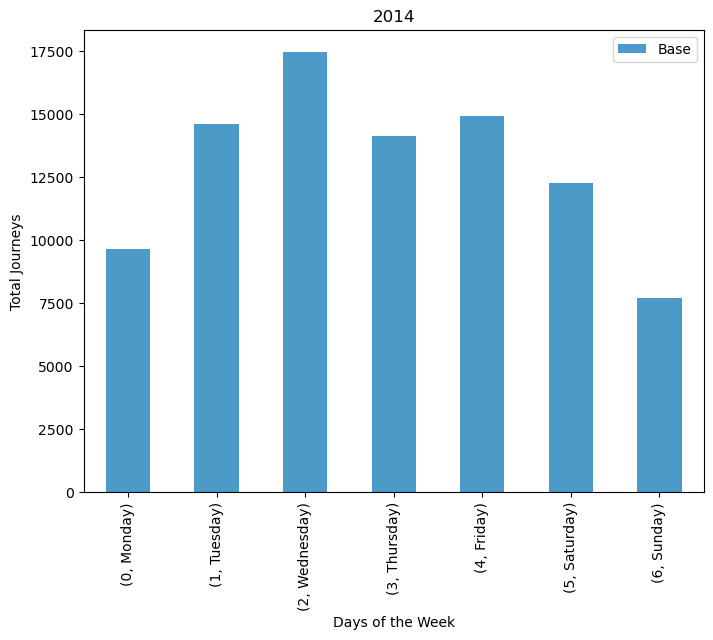

In [126]:
daily_uber_rides_2014 = df_sample.pivot_table(index=['day_num','dayofweek'],
                                  values='Base',
                                  aggfunc='count')
daily_uber_rides_2014.plot(kind='bar',figsize=(8,6), ylabel='Total Journeys', xlabel='Days of the Week', title ='2014', color='#4B9AC7')


<Axes: title={'center': '2015'}, xlabel='Days of the Week', ylabel='Total Journeys'>

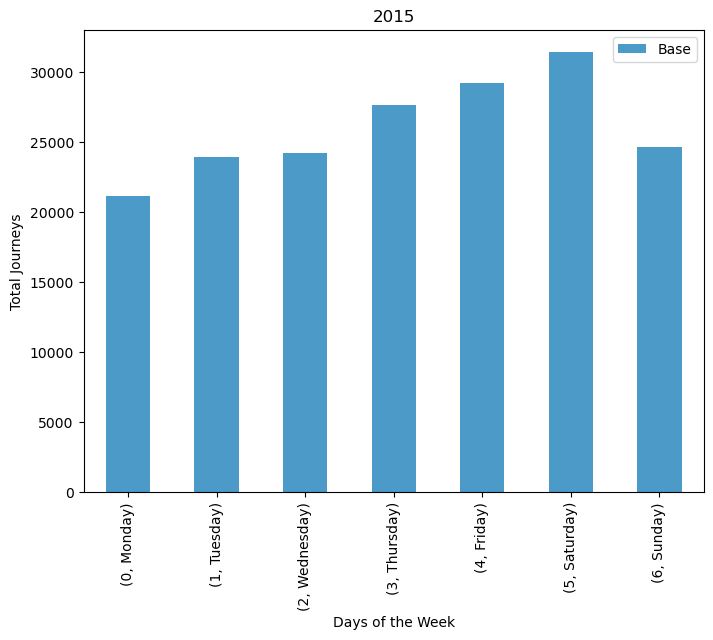

In [127]:
daily_uber_rides_2015 = df_sample_1.pivot_table(index=['day_num','dayofweek'],
                                  values='Base',
                                  aggfunc='count')
daily_uber_rides_2015.plot(kind='bar',figsize=(8,6), ylabel='Total Journeys', xlabel='Days of the Week', title ='2015', color='#4B9AC7')

In [128]:
## groupby operation 2014
daily_uber_rides_month_2014 = df_sample.groupby(['month','day_num','dayofweek'])['Base'].count()
#daily_uber_rides_month_2014 = daily_uber_rides_month_2014.reset_index()
daily_uber_rides_month_2014.head()
daily_uber_rides_month_2014.index

MultiIndex([(4, 0,    'Monday'),
            (4, 1,   'Tuesday'),
            (4, 2, 'Wednesday'),
            (4, 3,  'Thursday'),
            (4, 4,    'Friday'),
            (4, 5,  'Saturday'),
            (4, 6,    'Sunday'),
            (5, 0,    'Monday'),
            (5, 1,   'Tuesday'),
            (5, 2, 'Wednesday'),
            (5, 3,  'Thursday'),
            (5, 4,    'Friday'),
            (5, 5,  'Saturday'),
            (5, 6,    'Sunday'),
            (6, 0,    'Monday'),
            (6, 1,   'Tuesday'),
            (6, 2, 'Wednesday'),
            (6, 3,  'Thursday'),
            (6, 4,    'Friday'),
            (6, 5,  'Saturday'),
            (6, 6,    'Sunday'),
            (7, 0,    'Monday'),
            (7, 1,   'Tuesday'),
            (7, 2, 'Wednesday'),
            (7, 3,  'Thursday'),
            (7, 4,    'Friday'),
            (7, 5,  'Saturday'),
            (7, 6,    'Sunday'),
            (8, 0,    'Monday'),
            (8, 1,   'Tuesday'),
          

In [129]:
## groupby operation 2015
daily_uber_rides_month_2015 = df_sample_1.groupby(['month','day_num','dayofweek'])['Base'].count()
daily_uber_rides_month_2015 = daily_uber_rides_month_2015.reset_index()
daily_uber_rides_month_2015.head()

,month,day_num,dayofweek,Base
0,1,0,Monday,2424
1,1,1,Tuesday,2624
2,1,2,Wednesday,3223
3,1,3,Thursday,4349
4,1,4,Friday,4414


In [135]:
## create figure


ax = px.scatter(daily_uber_rides_month_2014,x='dayofweek', y="Base", color="month",labels={
                     "dayofweek": "Day of Week",
                     "Base": "Base",
                     "month": "month"
                 },  title='Total Number of Pickups for Each Weekday per Month (April-September 2014)')
ax.show()
ax = px.line(daily_uber_rides_month_2015,x=daily_uber_rides_month_2014.index, y="Base", color="month",labels={
                     "dayofweek": "Day of Week",
                     "Base": "Base",
                     "month": "month"
                 },  title='Total Number of Pickups for Each Weekday per Month (April-September 2015)')
ax.show()


ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['Base'] but received: dayofweek

In [ ]:
uber_hour_2014 = df_sample.pivot_table(index='hour',
                                  values='Base',
                                  aggfunc='count')
fig=px.bar(uber_hour_2014, labels={'HourOfDay': 'hour of the day', 'Base': "Base", "count": 'Total Journeys'}, title="Journeys by Hour 2014")
fig.show()
uber_hour_2015 = df_sample_1.pivot_table(index='hour',
                                  values='Base',
                                  aggfunc='count')
fig=px.bar(uber_hour_2015, labels={'HourOfDay': 'hour of the day', 'Base': "Base", "count": 'Total Journeys'}, title="Journeys by Hour 2015")
fig.show()

In [ ]:
df_sample, df_sample_1                     

(            Lat      Lon    Base  hour  day_num  dayofweek  quarter  month  \
 257613  40.7638 -73.9961  B02617    10        4     Friday        2      4   
 9599    40.7474 -73.9864  B02512    12        0     Monday        3      9   
 561613  40.7397 -73.9867  B02764    16        2  Wednesday        2      4   
 58947   40.7358 -73.9759  B02598    17        5   Saturday        2      4   
 453914  40.7590 -73.9685  B02682    18        3   Thursday        2      4   
 ...         ...      ...     ...   ...      ...        ...      ...    ...   
 410779  40.7498 -73.9481  B02682    16        4     Friday        2      4   
 8826    40.7652 -73.9837  B02512    19        0     Monday        2      4   
 28544   40.7482 -74.0031  B02512    22        4     Friday        2      4   
 386383  40.7512 -74.0066  B02682     9        1    Tuesday        2      4   
 111267  40.8224 -73.9407  B02598    19        1    Tuesday        2      4   
 
         year  dayofyear  dayofmonth  weekofyear  

In [ ]:
df_2014_2015=pd.concat([df_sample,df_sample_1], ignore_index=True,axis=0)

In [ ]:
df_2014_2015

,Lat,Lon,Base,hour,day_num,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
0,40.763800,-73.996100,B02617,10,4,Friday,2,4,2014,101,11,15
1,40.747400,-73.986400,B02512,12,0,Monday,3,9,2014,251,8,37
2,40.739700,-73.986700,B02764,16,2,Wednesday,2,4,2014,113,23,17
3,40.735800,-73.975900,B02598,17,5,Saturday,2,4,2014,95,5,14
4,40.759000,-73.968500,B02682,18,3,Thursday,2,4,2014,107,17,16
...,...,...,...,...,...,...,...,...,...,...,...,...
272917,40.727635,-73.996964,B02765,17,5,Saturday,1,3,2015,66,7,10
272918,40.731907,-73.994202,B02682,16,3,Thursday,1,1,2015,22,22,4
272919,40.625196,-74.029246,B02765,9,3,Thursday,2,4,2015,120,30,18
272920,40.753386,-73.988716,B02682,10,5,Saturday,2,6,2015,171,20,25


In [ ]:

df_2014_2015.reset_index(inplace=True)
fig=px.scatter_map(df_2014_2015, lat="Lat", lon="Lon",
               color='dayofweek', title= "2014-2015",zoom=8, animation_frame="year",
               map_style="open-street-map")

In [ ]:
fig.show()

In [ ]:
## get ride data
ride_data_2014 = df_sample
ride_data_2014 = df_sample[(df_sample['dayofmonth']== 21) & (df_sample['hour'] > 15)]

## maximum distance between two cluster members in kilometers
max_distance = 0.05#0.05

## minimum number of cluster members
min_pickups = 25

## call the get_hot_spots function
hot_spots_2014 = get_hot_spots(max_distance ,min_pickups, ride_data_2014)
hot_spots_2014

Number of clusters: 1


[[], [], []]

In [ ]:
## set the color scale
color_scale = np.log(hot_spots_2014[2])
# color_scale = hot_spots[2]

fig_dbscan_hot_spots_2014 = px.scatter_map(
        lat=hot_spots_2014[1],
        lon=hot_spots_2014[0],
        color=color_scale,
        zoom=5,
        map_style="basic",
        title="Clusters of Uber Pickups Hot Spots on 2014"
)
#map_style (str (default 'basic')) – Identifier of base map style. 
# Allowed values are    'basic', 'carto-darkmatter', 'carto-darkmatter-nolabels', 
#                       'carto-positron', 'carto-positron-nolabels', 'carto-voyager',
#                        'carto-voyager-nolabels', 'dark', 'light', 
#                        'open-street-map', 'outdoors', 'satellite',
#                        'satellite-streets', 'streets', 'white-bg'.
fig_dbscan_hot_spots_2014.show()


In [ ]:
numeric_features = ["Lat", "Lon"] # Positions des colonnes quantitatives dans X
category_feature=["Base","dayofweek"]
#df_sample=df_sample[df_sample['dayofweek']=="Thursday"] 

numeric_transformer = StandardScaler()  ####### utile de standard scaler ? on perd pas de l'info sur la distance hmmm ?
category_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer( transformers= [
    ('num', numeric_transformer, numeric_features),
    ('cat', category_transformer, category_feature)
], remainder='passthrough')


X_2014 = preprocessor.fit_transform(df_sample)



db = DBSCAN(eps=0.2, min_samples=10 , metric='manhattan')

db.fit(X_2014)

,eps,0.2
,min_samples,10
,metric,'manhattan'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [ ]:
np.unique(db.labels_)
df_sample["cluster"] = db.labels_
df_sample.head()

,Lat,Lon,Base,hour,day_num,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,cluster
257613,40.7638,-73.9961,B02617,10,4,Friday,2,4,2014,101,11,15,-1
9599,40.7474,-73.9864,B02512,12,0,Monday,3,9,2014,251,8,37,-1
561613,40.7397,-73.9867,B02764,16,2,Wednesday,2,4,2014,113,23,17,-1
58947,40.7358,-73.9759,B02598,17,5,Saturday,2,4,2014,95,5,14,-1
453914,40.7590,-73.9685,B02682,18,3,Thursday,2,4,2014,107,17,16,-1


In [ ]:
fig_dbscan_2014 = px.scatter_map(
        df_sample[df_sample["cluster"]>-1],
        lat="Lat",
        lon="Lon",
        color="cluster",
        zoom=10,
        map_style="carto-positron",
        title="Clusters of Uber Pickups on Saturdays"
)

fig_dbscan_2014.show()

## 2015


In [ ]:
df_sample_1.index

Index([   14294,  8730642,  1096207,  4108930,  7751509,  6368937,  7079836,
        7333051,  3550479,  3843001,
       ...
        2072015,  2139637, 12372499, 11535897, 11355654, 12591974, 10168630,
       14011834,  1966030, 10423230],
      dtype='int64', length=182238)

In [ ]:
## get ride data
ride_data_2015 = df_sample_1[(df_sample_1['dayofmonth']== 21) & (df_sample_1['hour'] > 15)]

## maximum distance between two cluster members in kilometers
max_distance = 0.05

## minimum number of cluster members
min_pickups = 25

## call the get_hot_spots function
hot_spots_2015 = get_hot_spots(max_distance ,min_pickups, ride_data_2015)

Number of clusters: 45


In [ ]:
## set the color scale
color_scale = np.log(hot_spots_2015[2])
# color_scale = hot_spots[2]

fig_dbscan_hot_spots_2015 = px.scatter_mapbox(
        lat=hot_spots_2015[1],
        lon=hot_spots_2015[0],
        color=color_scale,
        zoom=10,
        mapbox_style="carto-positron",
        title="Clusters of Uber Pickups Hot Spots on 2015"
)

fig_dbscan_hot_spots_2015.show()


/var/folders/6m/4bfx39_j0519_3g3r0sp6fbw0000gn/T/ipykernel_21301/324138987.py:5: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [ ]:
numeric_features = ["Lat", "Lon"] # Positions des colonnes quantitatives dans X

category_features=["Base","dayofweek"]
#df_sample=df_sample[df_sample['dayofweek']=="Thursday"] 

numeric_transformer = StandardScaler()  ####### utile de standard scaler ? on perd pas de l'info sur la distance hmmm ?
category_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer( transformers= [
    ('num', numeric_transformer, numeric_features),
    ('cat', category_transformer, category_features)
], remainder='passthrough')


X_2015 = preprocessor.fit_transform(df_sample_1)

db = DBSCAN(eps=0.2, min_samples=10 , metric='manhattan')

db.fit(X_2015)

np.unique(db.labels_)
df_sample_1['cluster'] = db.labels_
df_sample_1.head()

fig_dbscan_2015 = px.scatter_mapbox(
        df_sample_1[df_sample_1["cluster"]>-1],
        lat="Lat",
        lon="Lon",
        color="cluster",
        zoom=7,
        mapbox_style="carto-positron",
        title="Clusters of Uber Pickups on Saturdays"
)

fig_dbscan_2015.show()

ValueError: Found array with 0 sample(s) (shape=(0, 2)) while a minimum of 1 is required by StandardScaler.

## Carte thermique des trajets
Créons une carte thermique des prises en charge pour visualiser la répartition des pick-ups à New York sur ces mois, afin de repérer les zones très sollicitées et celles qui le sont moins. Nous utilisons pour cela le paquet Basemap afin de générer la visualisation cartographique.

In [ ]:
west, south, east, north = -74.26, 40.50, -73.70, 40.92

import plotly.express as px

# Data with latitude/longitude and values
uber_rides_2014_2015 = df_sample.groupby(['Lat','Lon'])['Base'].count()

In [ ]:
uber_rides_2014_2015.index

MultiIndex([( 40.112, -74.0343),
            (40.2736, -74.0097),
            (40.3676, -74.0115),
            (40.5753, -73.9841),
            (40.5755, -73.9766),
            (40.5755, -73.9611),
            (40.5757, -73.9808),
            (40.5757, -73.9507),
            (40.5763, -73.9699),
            (40.5768, -74.0032),
            ...
            ( 40.929, -73.9505),
            (40.9305, -73.9342),
            (40.9353, -74.0329),
            (40.9534, -74.0322),
            (40.9592, -73.9501),
            (40.9595, -74.0347),
            (40.9861, -74.0388),
            (40.9885, -73.9713),
            (40.9968, -74.0334),
            (41.3469, -73.9544)],
           names=['Lat', 'Lon'], length=59017)

In [ ]:


fig = px.density_mapbox(uber_rides_2014_2015, lat = 'Lat', lon = 'Lon', z = 'Base',
                        radius = 7,
                        center = dict(lat = -74.0, lon = 40.7),
                        zoom = 6,
                        mapbox_style = 'open-street-map',
                        color_continuous_scale = 'rainbow')
fig.show()

/var/folders/6m/4bfx39_j0519_3g3r0sp6fbw0000gn/T/ipykernel_21301/2526980364.py:8: DeprecationWarning:

*density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



ValueError: Value of 'lat' is not the name of a column in 'data_frame'. Expected one of ['Base'] but received: Lat

## Essai avec le K-Means pour faire des clusters

In [ ]:
# Import K-Means
from sklearn.cluster import KMeans

# Instanciate KMeans with k=3 and initialisation with k-means++
# You should always use k-means++ as it alleviate the problem of local minimum convergence
kmeans = KMeans(n_clusters=5, random_state=0)

# Fit kmeans to our dataset
kmeans.fit(X_2014)
cluster = kmeans.predict(X_2014)
df_sample['cluster-kmeans'] = pd.DataFrame(cluster, columns=['cluster'])
df_sample.head(30)
cluster
print()
fig = px.scatter_mapbox(
        df_sample,
        lat="Lat",
        lon="Lon",
        color="cluster-kmeans",
        zoom=6,
        mapbox_style="carto-positron"
)

fig.show()

In [ ]:
# Let's create a loop that will collect the Within-sum-of-square (wcss) for each value K
# Let's use .inertia_ parameter to get the within sum of square value for each value K
wcss =  []
k = []
for i in range (1,11):
    kmeans = KMeans(n_clusters= i, random_state = 0, n_init = 'auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    k.append(i)
    print("WCSS for K={} --> {}".format(i, wcss[-1]))

In [ ]:
# Create DataFrame
wcss_frame = pd.DataFrame(wcss)
k_frame = pd.Series(k)

# Create figure
fig= px.line(
    wcss_frame,
    x=k_frame,
    y=wcss_frame.iloc[:,-1]
)

# Create title and axis labels
fig.update_layout(
    yaxis_title="Inertia",
    xaxis_title="# Clusters",
    title="Inertia per cluster"
)

# Render
#fig.show(renderer="notebook")
fig.show() # if using workspace

In [ ]:
# Import silhouette score
from sklearn.metrics import silhouette_score

# Computer mean silhouette score
sil = []
k = []

## Careful, you need to start at i=2 as silhouette score cannot accept less than 2 labels
for i in range (2,11):
    kmeans = KMeans(n_clusters= i, random_state = 0, n_init = 'auto')
    kmeans.fit(X)
    sil.append(silhouette_score(X, kmeans.predict(X)))
    k.append(i)
    print("Silhouette score for K={} is {}".format(i, sil[-1]))

In [ ]:
# Create a data frame
cluster_scores=pd.DataFrame(sil)
k_frame = pd.Series(k)

# Create figure
fig = px.bar(data_frame=cluster_scores,
             x=k,
             y=cluster_scores.iloc[:, -1]
            )

# Add title and axis labels
fig.update_layout(
    yaxis_title="Silhouette Score",
    xaxis_title="# Clusters",
    title="Silhouette Score per cluster"
)

# Render
#fig.show(renderer="notebook")
fig.show() # if using workspace